# Single-phase MC-PILCO — evaluation & comparison

Notebook counterpart to `evaluations_single_phase.py` (the CLI script) — both import every
plot/table from `eval_single_phase_lib.py`, so there is exactly one implementation and running
either produces the same saved PNGs/CSVs in the run's own folder
(`results/single_phase/<run_id>/`).

Set `RUN_ID` in the **Config** cell (e.g. `"seed3_104"`) and run top-to-bottom — everything else
(seed, num_trials, fast, optim_horizon/anchors, the trained policy, the trained GPs) is read
back from that run's own `note.txt`/`log.pkl`/`monitor.pkl`.

- **A** — RL policy vs same-seed PID/recipe baseline (paired yield statistics + seed-averaged
  trajectories + validation learning curve).
- **B** — training progression (per-episode trajectories, all observations, Fs residual).
- **C** — GP model diagnostics: one-step fit/R^2, per-dim MSE, multi-step rollout, particle
  bands & calibration, local error across the batch, k-step-ahead error growth, and (only for
  runs that actually used anchors -- `--optim_horizon`/`--num_anchor_batches`) the
  short-horizon optimiser-window / recipe-anchor diagnostic.

Replaces the previous inline version of this notebook, which had two latent bugs: several
names it used (`torch`, `STATE_RANGES`, `X_IDX`/`P_IDX`, etc.) were never actually imported in
the committed source, and it hardcoded `T_SAMPLING = 2.0` despite the real trained decision
spacing being 5h. `eval_single_phase_lib.py` imports everything explicitly and uses the real
`T_SAMPLING` throughout.


## 0. Setup & Config

In [1]:
%matplotlib inline
import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
if _ROOT not in _sys.path:
    _sys.path.insert(0, _ROOT)

import evaluations.eval_single_phase_lib as lib

RUN_ID = "seed3_104"        # resolved under results/single_phase/, or a full/relative path
GP_TRIAL = None             # which trial's GP model to diagnose in section C (None = last saved)
N_EVAL_SEEDS = 5            # held-out seeds for section A
EVAL_BASE = 700000
COMPARE_SEED = EVAL_BASE

run = lib.load_run(RUN_ID)
OUT_DIR = run.dir
run.params


log/code state check OK: state_dim=5, channels=['Wt', 'X', 'P', 'Viscosity', 'time']
run: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/seed3_104  |  episodes: 10  |  trials in log: 5


{'seed': 3,
 'num_trials': 5,
 'fast': False,
 'out_dir': '/home/s2889898/Diss/pensim_mcpilco/pensim_mcpilco/results/cluster/full/seed3_104',
 'optim_horizon': None,
 'num_anchor_batches': 0,
 'num_anchors': 12,
 'anchor_var': 0.01,
 'risk_weight': 0.0,
 'visc_penalty': 0.5,
 'harvest_reward': True,
 'num_high_feed_probes': 0}

# A. RL policy vs same-seed PID baseline

The recipe/PID baseline runs on the **same seed** as the RL policy, so each pair shares an
identical stochastic batch realisation and only the Fs (sugar-feed) action differs. Evaluated
on a block of held-out seeds disjoint from training.

In [2]:
policy_agent, eval_wrapper, np_policy, ref, ref_lbl = lib.build_policy_agent(run)




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


[recipe-mean] Viscosity: 45 decisions from 4 recipe batches, normalised delta range [-0.1081, 0.0977]


Get the exploration policy...


Get the control policy...


Get the cost function...


loaded trial 5 policy | recipe baseline on seed 3000: final_P=25.61 g/L, yield=3246.7 kg


## A.1-A.2 Held-out evaluation & paired statistics

In [3]:
df, mons_rl, mons_recipe = lib.eval_held_out(
    run, np_policy, eval_wrapper, OUT_DIR, n_eval_seeds=N_EVAL_SEEDS, eval_base=EVAL_BASE)
df


seed 700000: yield_rl= 3371.03  yield_recipe= 3467.33  delta=  -96.29


seed 700001: yield_rl= 4100.29  yield_recipe= 3573.90  delta= +526.39


seed 700002: yield_rl= 3040.56  yield_recipe= 3696.62  delta= -656.06


seed 700003: yield_rl= 3903.64  yield_recipe= 3526.59  delta= +377.05


seed 700004: yield_rl= 3291.27  yield_recipe= 3214.51  delta=  +76.76


,seed,yield_rl,yield_recipe,delta,rl_final_P,rl_max_Wt,rl_wt_overflow,rl_paa_frac_out_of_band,rl_max_viscosity,rl_visc_exceed,recipe_final_P,recipe_max_Wt,recipe_wt_overflow,recipe_paa_frac_out_of_band,recipe_max_viscosity,recipe_visc_exceed
0,700000,3371.034973,3467.328902,-96.293930,26.215862,107427.835475,False,0.011304,95.505440,False,27.424360,101050.051771,False,0.011304,81.007048,False
1,700001,4100.291341,3573.899211,526.392131,29.906907,112983.593152,False,0.019130,78.318970,False,27.762091,106086.753636,False,0.019130,71.801539,False
2,700002,3040.555243,3696.618223,-656.062980,23.890981,102686.868142,False,0.000000,111.197316,True,30.024651,98603.657446,False,0.000000,89.916614,False
3,700003,3903.640351,3526.588600,377.051751,28.574094,112069.988946,False,0.020000,83.903385,False,27.108314,105621.700489,False,0.020870,75.306299,False
4,700004,3291.271132,3214.506607,76.764525,24.828973,110294.482664,False,0.023478,96.641422,False,24.884472,101732.672304,False,0.024348,79.894066,False


In [4]:
summary = lib.paired_stats(df, OUT_DIR)
summary


=== SUMMARY (RL vs recipe, held-out) ===
n_seeds                  5.000000
mean_yield_rl         3541.358608
mean_yield_recipe     3495.788309
mean_delta              45.570299
delta_ci95_lo         -359.552120
delta_ci95_hi          450.692719
ttest_p                  0.836300
wilcoxon_p               1.000000
winrate_rl_gt_recipe     0.600000


,n_seeds,mean_yield_rl,mean_yield_recipe,mean_delta,delta_ci95_lo,delta_ci95_hi,ttest_p,wilcoxon_p,winrate_rl_gt_recipe
0,5,3541.358608,3495.788309,45.570299,-359.55212,450.692719,0.8363,1.0,0.6


## A.3-A.5 Paired yield / total yield / seed-averaged variables

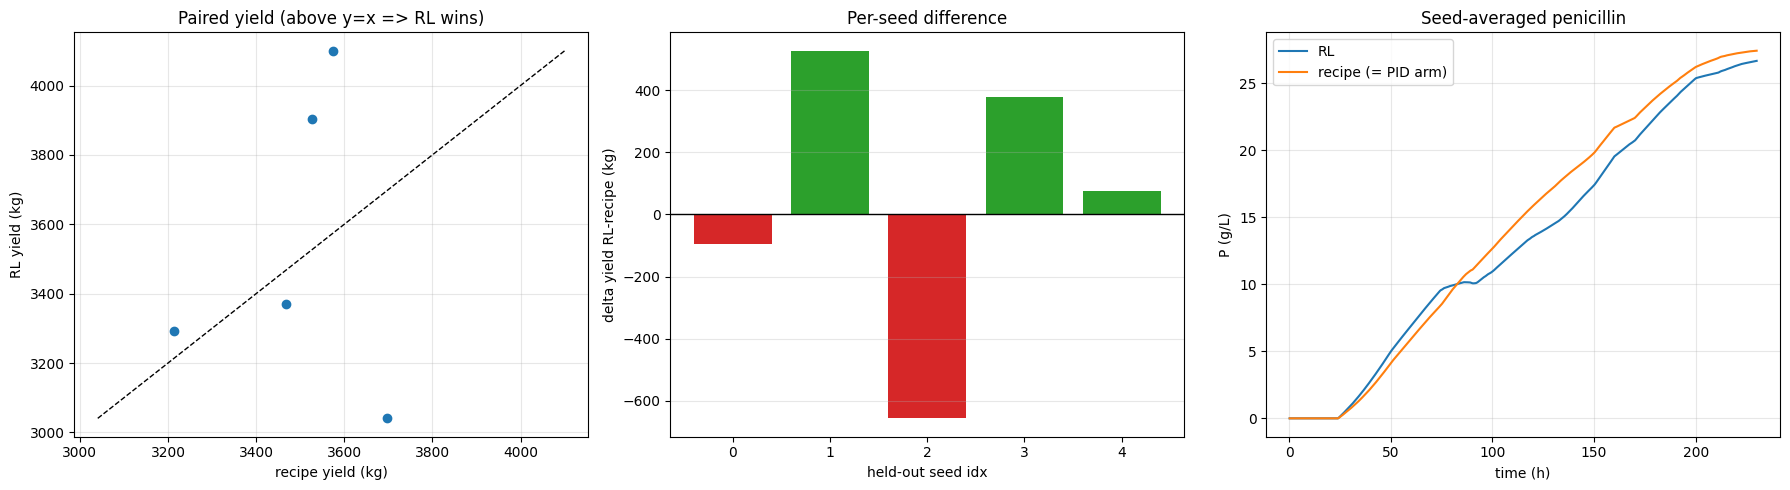

In [5]:
lib.plot_paired_yield(df, mons_rl, mons_recipe, OUT_DIR, show=True);


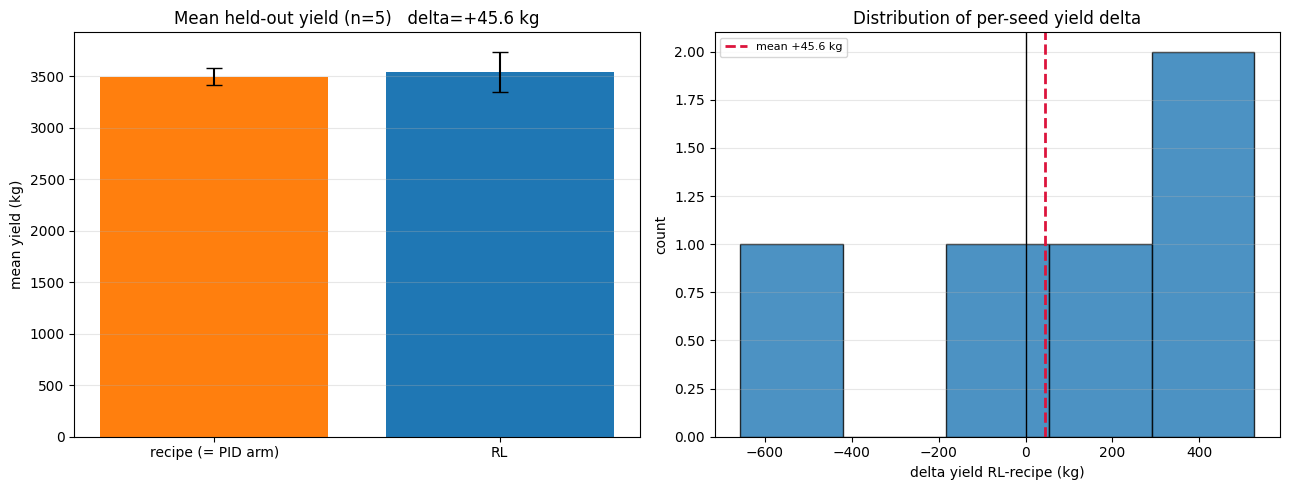

In [6]:
lib.plot_total_yield(df, OUT_DIR, show=True);


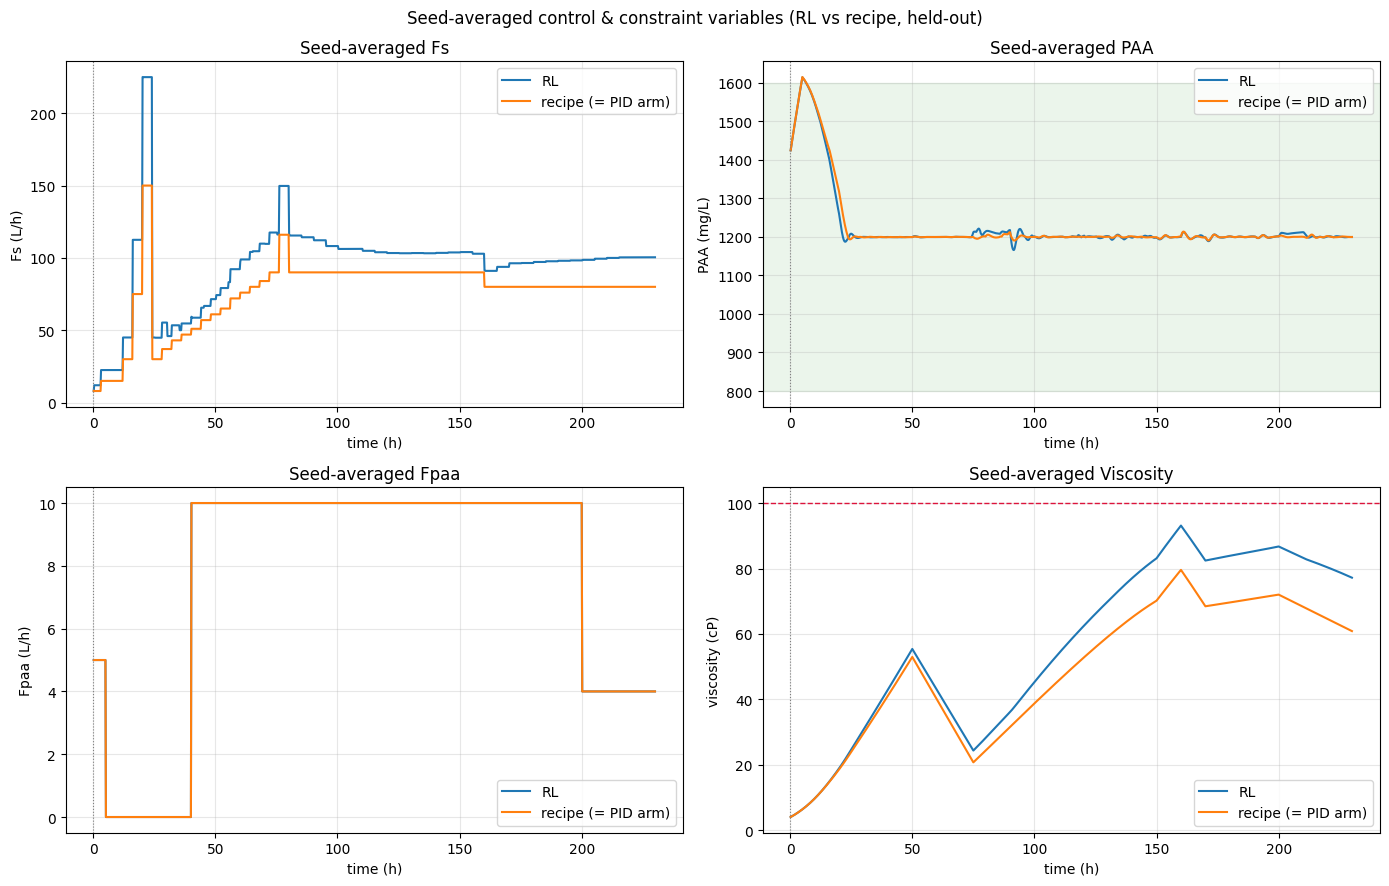

In [7]:
lib.plot_seed_avg_vars(mons_rl, mons_recipe, OUT_DIR, show=True);


## A.6-A.7 Model vs recipe on a single shared seed, Fs residual

seed 700000: yield model= 3371.03 kg  recipe= 3467.33 kg  delta=  -96.29 kg


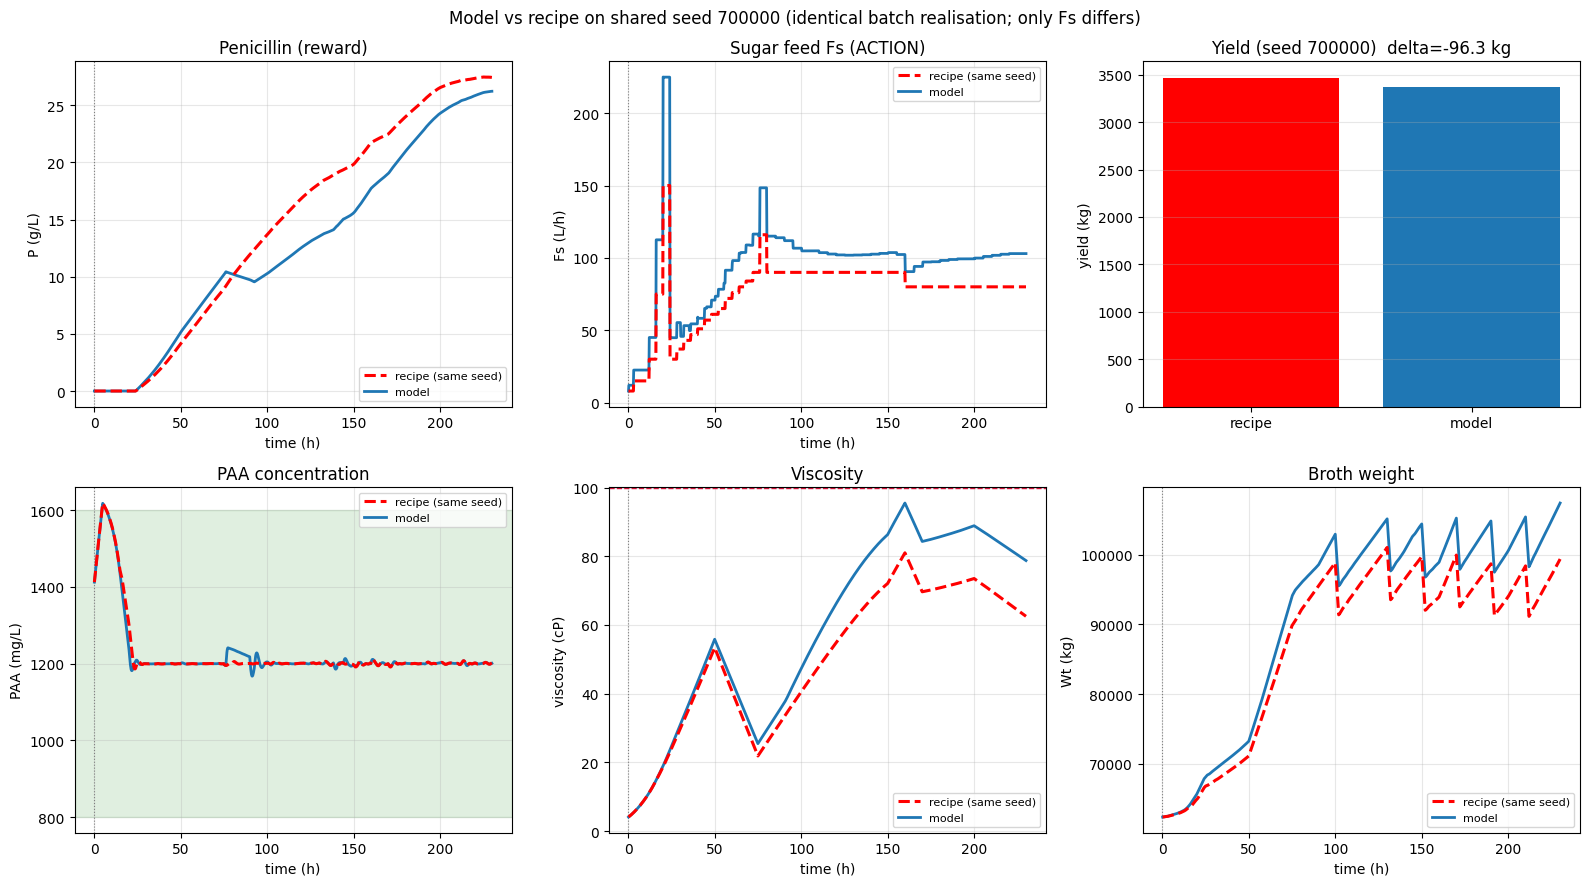

In [8]:
_, m_rl_s, m_recipe_s = lib.plot_model_vs_recipe_single_seed(
    eval_wrapper, np_policy, COMPARE_SEED, OUT_DIR, show=True)


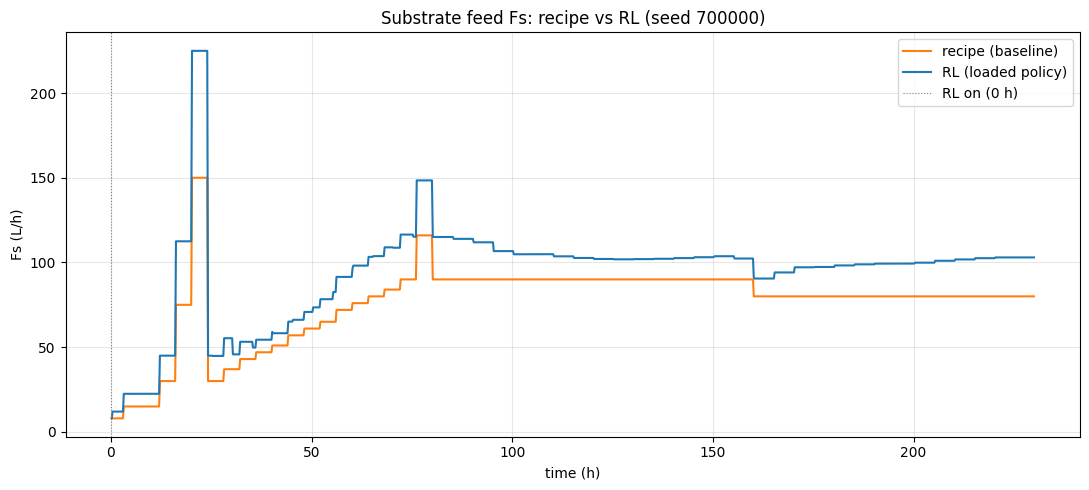

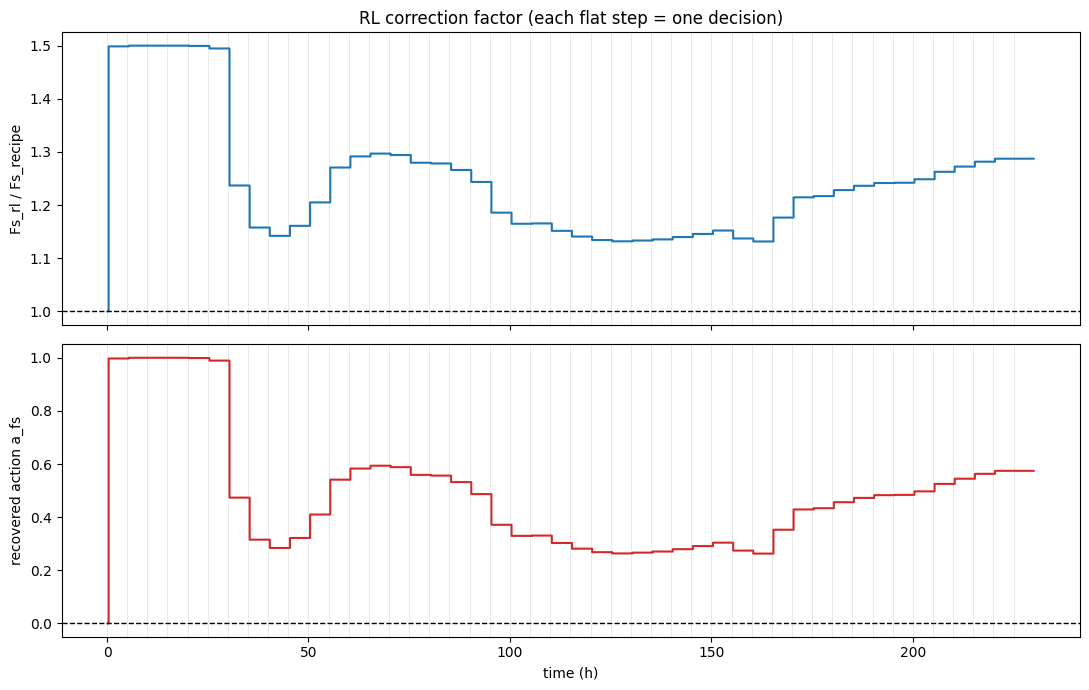

distinct action levels held over the batch: 46 (expected ~45 at T_SAMPLING=5 h)


In [9]:
lib.plot_fs_residual(m_rl_s, m_recipe_s, COMPARE_SEED, OUT_DIR, show=True);


## A.8 Validation learning curve (fixed seeds) — does the policy actually improve?

Seeds are held fixed and only the policy stage varies (loaded from `log["parameters_trial_list"]`),
each stage paired against the recipe on the same seed -- so seed variance cancels and any trend
is genuinely the policy.

recipe baseline on [700000, 700001, 700002]: 3579.3 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  1: yield=  3747.1 +/-  96.9 kg | paired delta vs recipe =   +167.8 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  2: yield=  3590.2 +/- 144.9 kg | paired delta vs recipe =    +10.9 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  3: yield=  3342.7 +/- 495.3 kg | paired delta vs recipe =   -236.5 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  4: yield=  3749.4 +/- 234.9 kg | paired delta vs recipe =   +170.1 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  5: yield=  3504.0 +/- 442.7 kg | paired delta vs recipe =    -75.3 kg


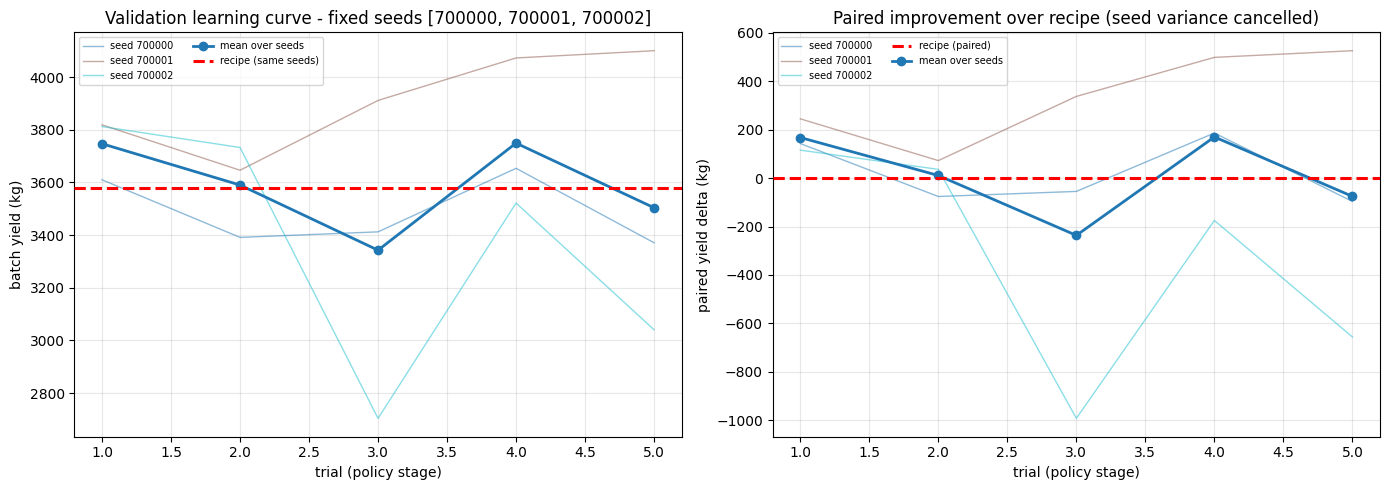

final policy: 3504.0 kg vs recipe 3579.3 kg (paired delta -75.3 kg) -> BELOW recipe


,trial,mean_yield,std_yield,paired_delta
0,1,3747.084550,96.869673,167.802438
1,2,3590.193227,144.907880,10.911115
2,3,3342.743844,495.317198,-236.538268
3,4,3749.405654,234.912870,170.123542
4,5,3503.960519,442.727945,-75.321593


In [10]:
eval_seeds = [EVAL_BASE + i for i in range(N_EVAL_SEEDS)]
VAL_SEEDS = eval_seeds[:-2] if len(eval_seeds) > 2 else eval_seeds
_, learning_curve_df = lib.validation_learning_curve(run, eval_wrapper, OUT_DIR, VAL_SEEDS, show=True)
learning_curve_df


# B. Training progression (single run, all episodes)

How the run evolved across episodes (grey = exploration, viridis early->late = trials),
overlaid with the fixed recipe reference batch.

## B.1 Reward, PAA, viscosity, Fpaa, penicillin trajectories, yield per episode

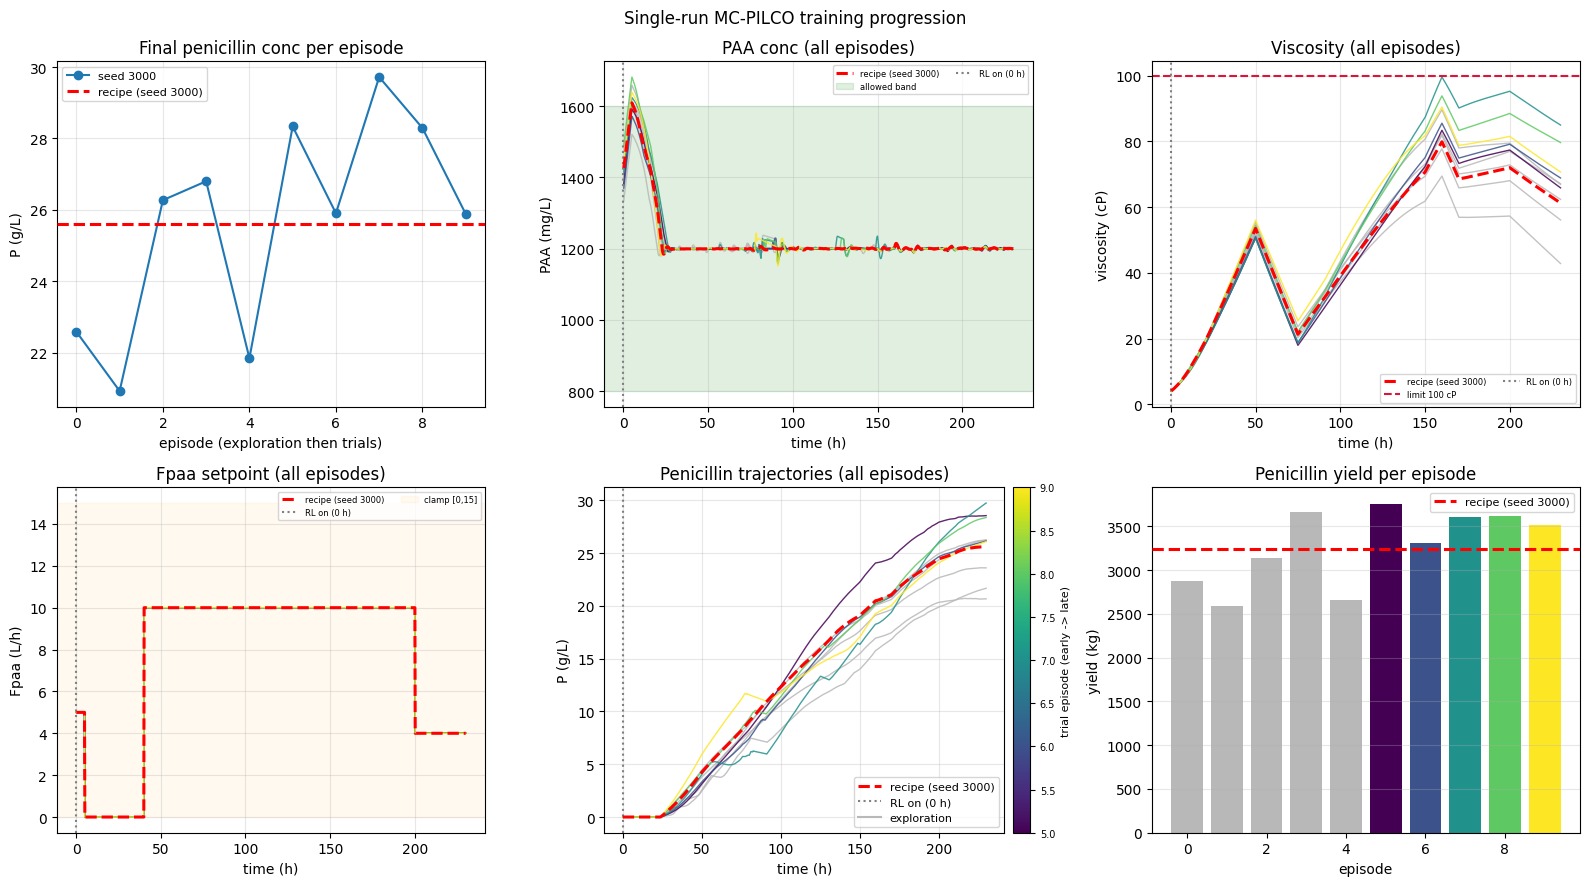

In [11]:
lib.plot_training_progression(run, ref, ref_lbl, OUT_DIR, show=True);


## B.2 All observations per episode

/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/evaluations/eval_single_phase_lib.py:703: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


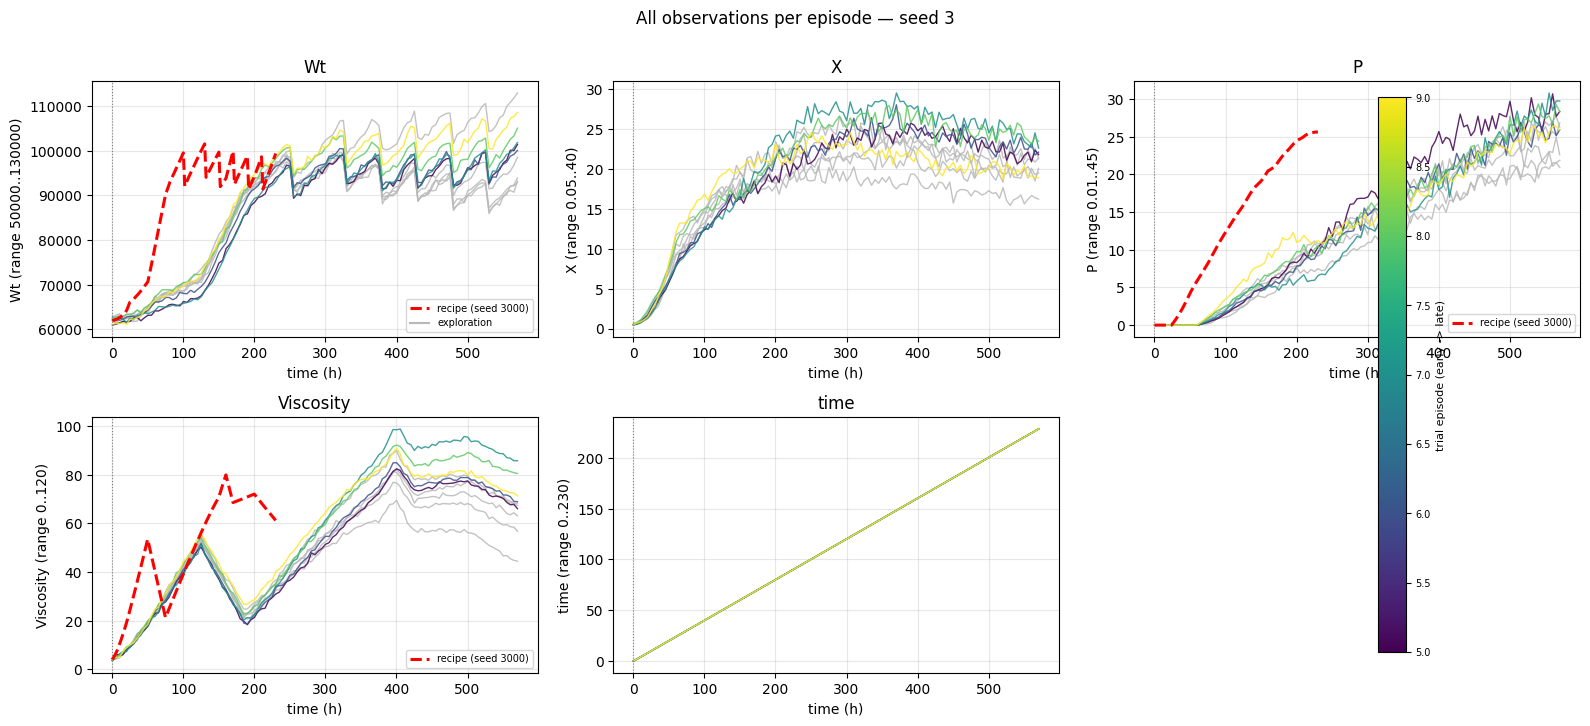

In [12]:
lib.plot_all_observations(run, ref, ref_lbl, OUT_DIR, show=True);


## B.3 Fs (sugar feed): recipe vs RL residual, all episodes

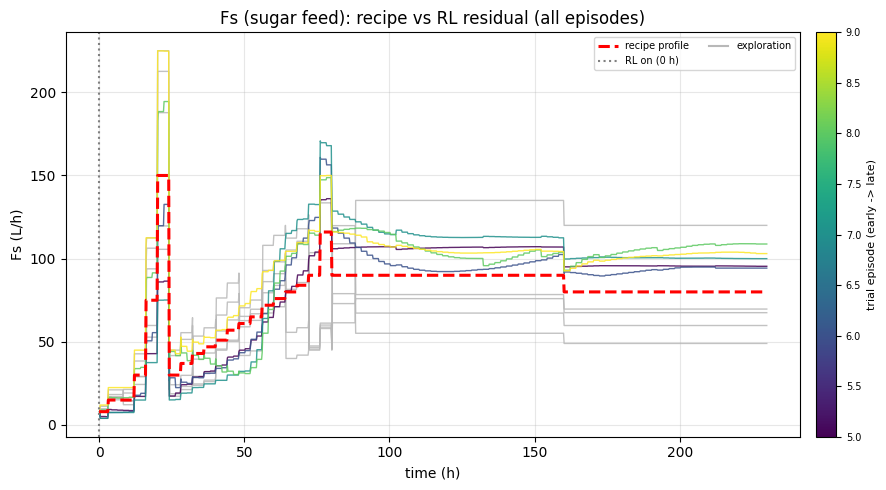

In [13]:
lib.plot_fs_all_episodes(run, OUT_DIR, show=True);


# C. GP model diagnostics

Is the learned GP dynamics model trustworthy over the horizon MC-PILCO optimises the policy
on? One-step fit, per-dim error, local error across the batch, k-step-ahead growth, and (if
the run used anchors) the short-horizon optimiser-window / recipe-anchor probe. In-sample =
the batch the GP trained on; held-out = the next batch (collected under the trial-idx
policy).

## C.1 Reconstruct the GP model

In [14]:
gp_agent, GP_IDX = lib.reconstruct_gp_agent(run, idx=GP_TRIAL)
ho_idx = GP_IDX + 1
has_ho = ho_idx < len(gp_agent.state_samples_history)
print(f"reconstructed GP model @ trial {GP_IDX} | has held-out batch: {has_ho}")




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...

Selection of the inducing inputs...


/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/MC-PILCO/gpr_lib/GP_prior/GP_prior.py:106: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:1776.)
  U = torch.cholesky(K_X, upper=True)


Shape inducing inputs selected: torch.Size([334, 6])
MSE gp 0:  tensor(0.0025, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([748, 6])
MSE gp 1:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([1026, 6])
MSE gp 2:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([261, 6])
MSE gp 3:  tensor(0.0014, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([518, 6])
MSE gp 4:  tensor(3.9912e-12, dtype=torch.float64)
reconstructed GP model @ trial 8 | has held-out batch: True


## C.1/C.3/C.4 One-step fit, per-dim MSE

MSE gp0:  0.002390479162785873
MSE gp1:  0.00016544035776357768
MSE gp2:  0.00010072748251923376
MSE gp3:  0.0014766788986453287
MSE gp4:  2.903462746922531e-12


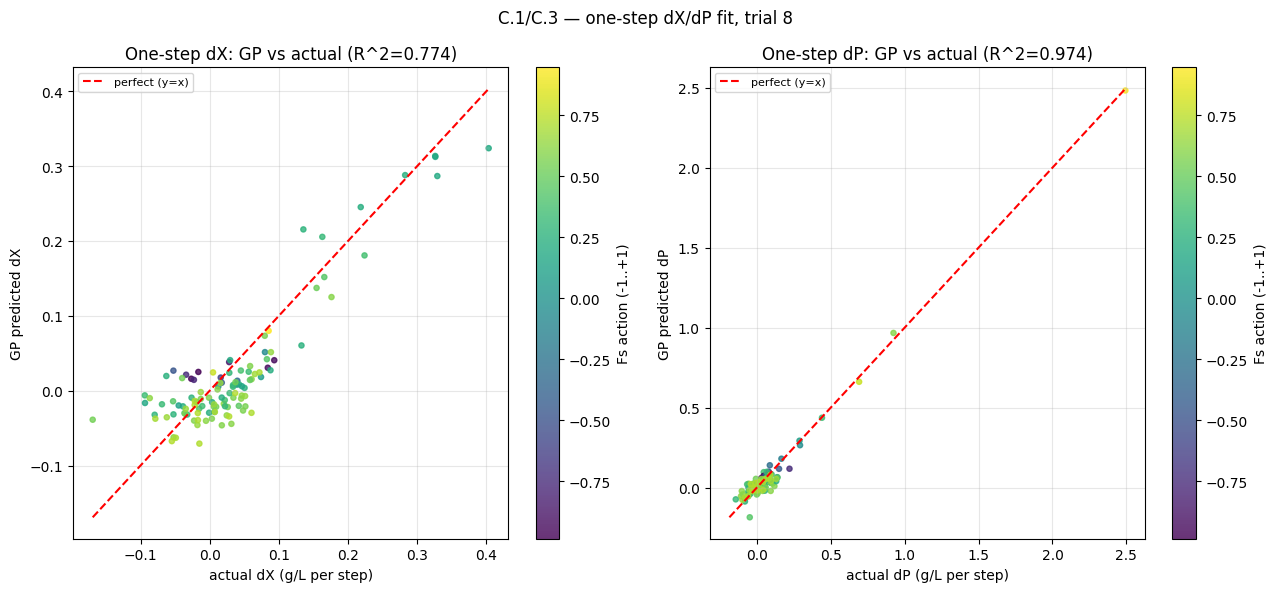

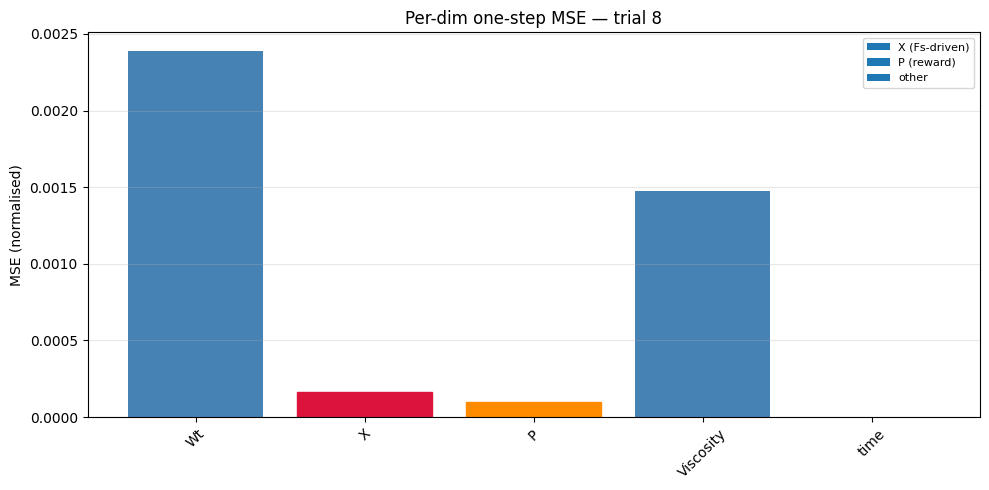

one-step R^2: X=0.774 P=0.974


In [15]:
per_dim_mse, one_step_results = lib.one_step_fit(gp_agent, GP_IDX, OUT_DIR, show=True)


## C.2 Multi-step X & P rollouts (in-sample vs held-out)

MSE Rollout dim0:  0.041588559054264014
MSE Rollout dim1:  0.008909460831710195
MSE Rollout dim2:  0.1897039198022377
MSE Rollout dim3:  1.1906814454729047
MSE Rollout dim4:  0.4788071077504722


MSE Rollout dim0:  0.0417321643109631
MSE Rollout dim1:  0.004372975805271853
MSE Rollout dim2:  0.16156299859085627
MSE Rollout dim3:  0.9871549359853644
MSE Rollout dim4:  0.4788071077504722


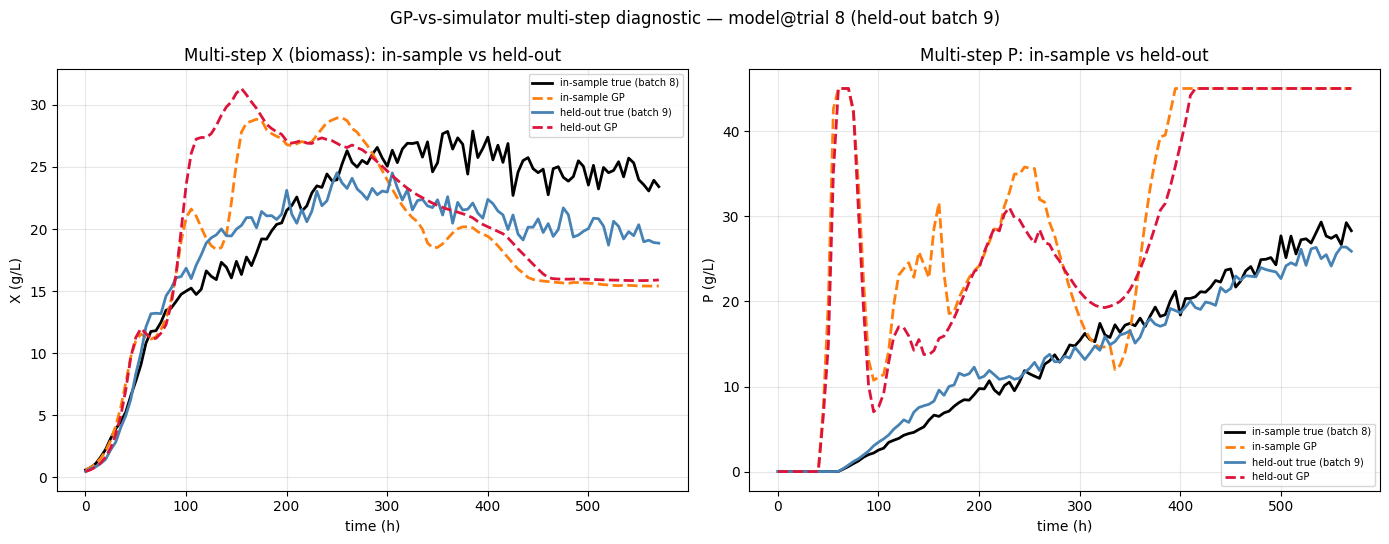

X rollout in-sample: final actual=23.41 g/L, GP=15.41 g/L
P rollout in-sample: final actual=28.29 g/L, GP=45.00 g/L


In [16]:
lib.plot_multistep_rollout(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.2b GP multi-step uncertainty — all channels, with the model's own uncertainty

The GP's particle band (10-90%) and median vs its deterministic mean rollout (= C.2) and the
true simulator trajectory, for every channel, in-sample and held-out.

MSE Rollout dim0:  0.041588559054264014
MSE Rollout dim1:  0.008909460831710195
MSE Rollout dim2:  0.1897039198022377
MSE Rollout dim3:  1.1906814454729047
MSE Rollout dim4:  0.4788071077504722


MSE Rollout dim0:  0.0417321643109631
MSE Rollout dim1:  0.004372975805271853
MSE Rollout dim2:  0.16156299859085627
MSE Rollout dim3:  0.9871549359853644
MSE Rollout dim4:  0.4788071077504722


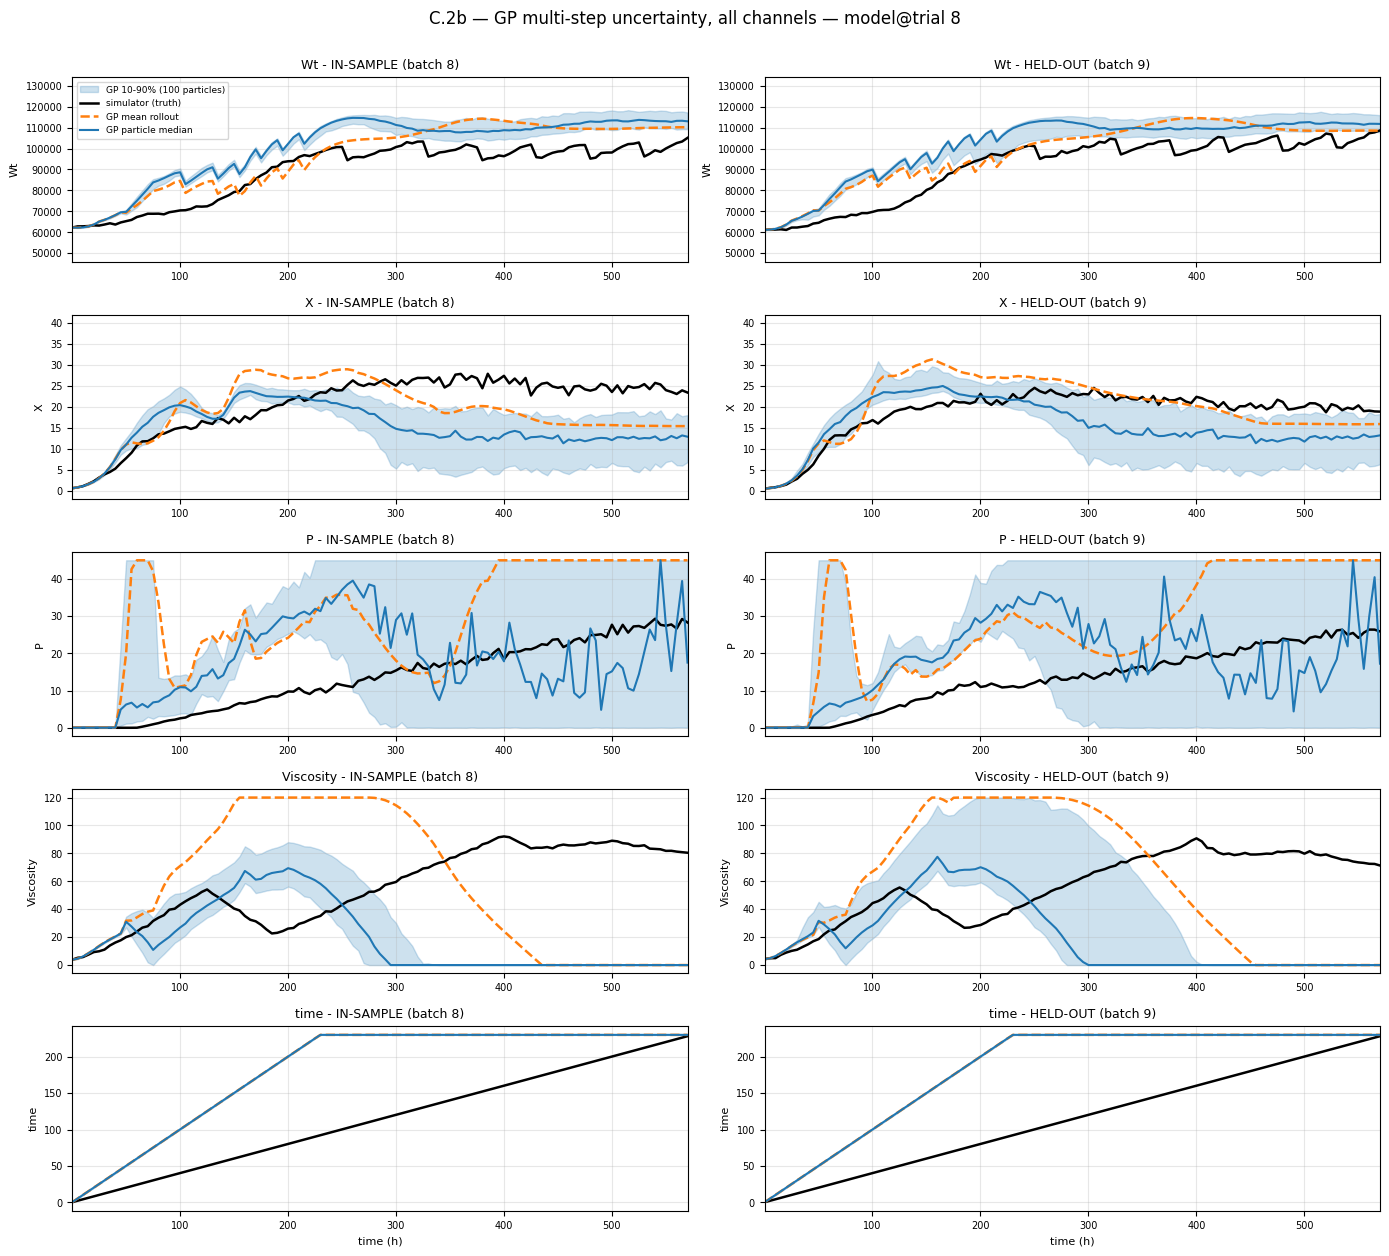

In [17]:
lib.plot_particle_bands(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.4b One-step teacher-forced standardised residuals (GP calibration)

`z = (predicted - true) / pred_std`; a well-calibrated channel is ~N(0,1). `time` is
deterministic (variance pinned to a tiny jitter) -- ignore its panel.

/Users/rokaspranevicius/miniforge3/envs/mcpilco/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


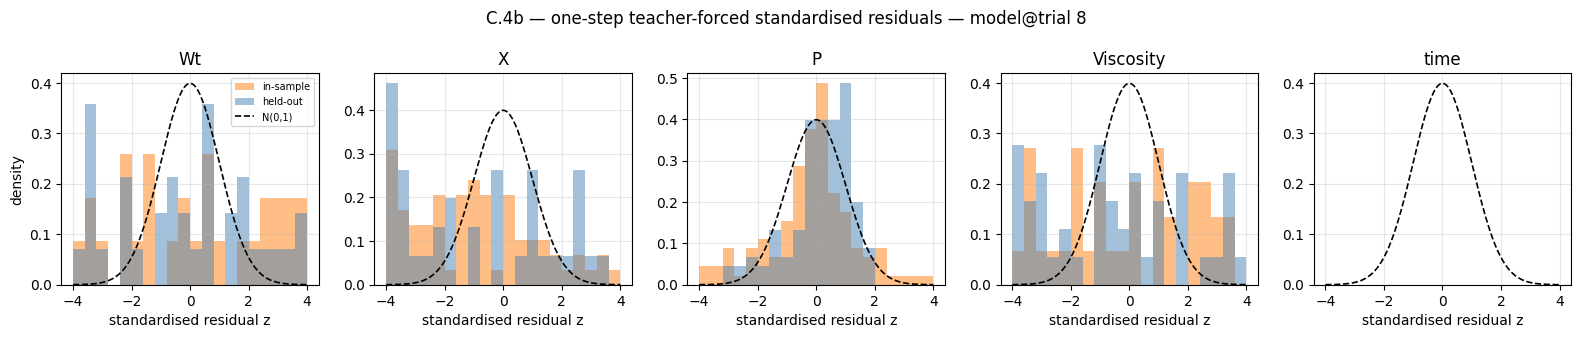

In [18]:
lib.plot_calibration(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.5 Local (one-step) error across the batch

Each estimate re-anchors on the truth, so there is no accumulation -- flat means late rollout
divergence is pure accumulation; growing late means a local model-quality problem.

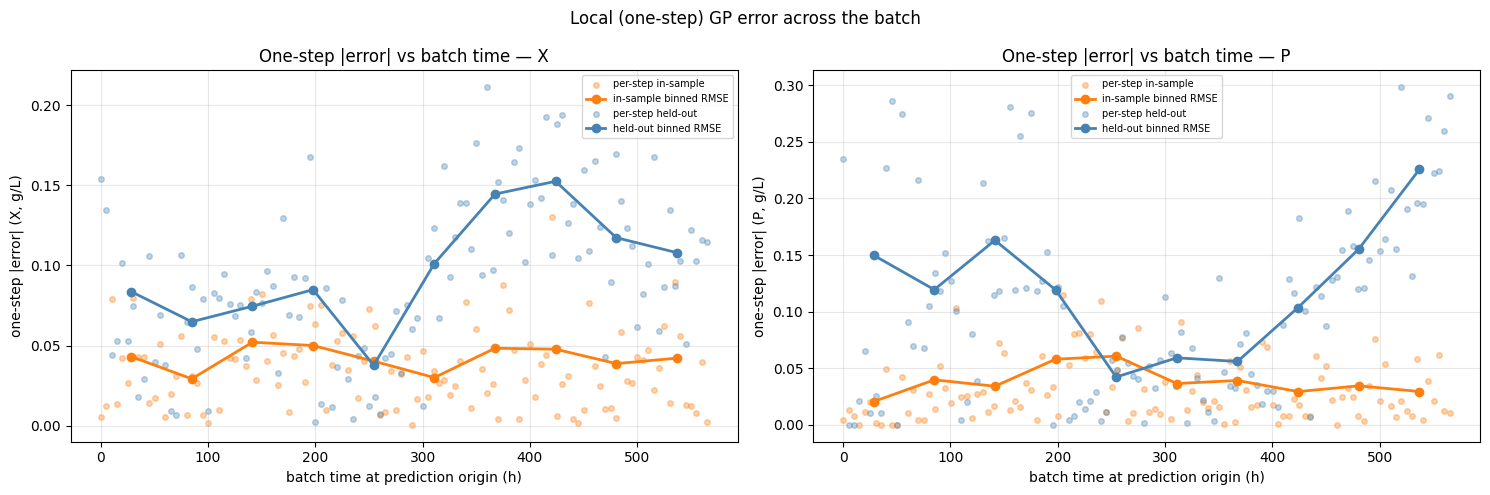

In [19]:
lib.plot_local_error(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.6 k-step-ahead prediction error growth

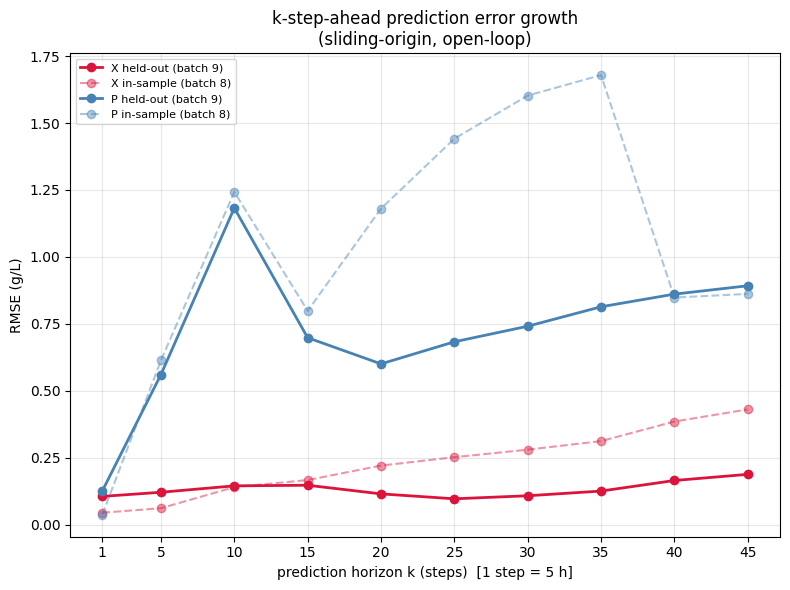

In [20]:
lib.plot_kstep_growth(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.7 Short-horizon diagnostic (optimiser window & recipe anchors)

Only meaningful for runs that used anchors (`--optim_horizon`/`--num_anchor_batches` on
`experiments/02_mcpilco_single_phase.py`). With the multi-origin short-horizon update, the
policy is optimised over many short H-step rollouts launched from recipe anchors, not one
long rollout: this probes (top-left) error growth inside vs beyond the H-step optimiser
window, (top-right) per-anchor H-step accuracy by batch phase, (bottom) each anchor's H-step
pure-GP rollout over the true recipe trajectory.

In [21]:
if run.has_anchors:
    lib.plot_short_horizon(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR,
                           run.optim_horizon, run.num_anchors, show=True)
else:
    print(f"skipped: run did not use anchors "
         f"(optim_horizon={run.optim_horizon}, num_anchors={run.num_anchors})")


skipped: run did not use anchors (optim_horizon=None, num_anchors=12)


---
### Notes
- All comparisons use the discharge-aware `yield_kg` metric from `experiments/eval_utils`,
  identical to what the recipe/BO baselines report.
- To evaluate a different run, change **RUN_ID** in the Config cell and re-run -- everything
  else is read back from that run's own files.
- Every plot/table above also wrote a PNG/CSV into `OUT_DIR` (the run's own folder); running
  `evaluations_single_phase.py <run_id>` from the command line produces the identical files
  without opening a notebook.
